# **Project**
In this project, we use publicly available e-commerce transaction data and supervised machine learning techniques to build a model that predicts which customers are most likely to become repeat purchasers. This will help WitOmni identify high-value customer segments, prioritize marketing efforts, and develop more effective customer retention strategies.

# **Imports and Setup**

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import tensorflow.keras as keras
from sklearn.preprocessing import StandardScaler
import time

In [ ]:
pip install ucimlrepo

## **`Task 2: Data Analysis & Cleaning`**

Now that we have the full dataframe, we can define the target variable `y`. A 'repeat purchaser' can be defined as a customer who has made more than one purchase. We can identify these customers by counting the number of unique `InvoiceNo` per `CustomerID`.

In [ ]:
#Initial data loading and prep — completed by Syeda
from ucimlrepo import fetch_ucirepo

# fetch dataset
online_retail = fetch_ucirepo(id=352)

# data (as pandas dataframes)
X = online_retail.data.features
y = online_retail.data.targets

# metadata
print(online_retail.metadata)

# variable information
print(online_retail.variables)

df = pd.concat([online_retail.data.ids, X], axis=1)

{'uci_id': 352, 'name': 'Online Retail', 'repository_url': 'https://archive.ics.uci.edu/dataset/352/online+retail', 'data_url': 'https://archive.ics.uci.edu/static/public/352/data.csv', 'abstract': 'This is a transactional data set which contains all the transactions occurring between 01/12/2010 and 09/12/2011 for a UK-based and registered non-store online retail.', 'area': 'Business', 'tasks': ['Classification', 'Clustering'], 'characteristics': ['Multivariate', 'Sequential', 'Time-Series'], 'num_instances': 541909, 'num_features': 6, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': None, 'index_col': ['InvoiceNo', 'StockCode'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2015, 'last_updated': 'Mon Oct 21 2024', 'dataset_doi': '10.24432/C5BW33', 'creators': ['Daqing Chen'], 'intro_paper': {'ID': 361, 'type': 'NATIVE', 'title': 'Data mining for the online retail industry: A case study of RFM model-based customer segmenta

This may be important from above

'variable_info': "InvoiceNo: Invoice number. Nominal, a 6-digit integral number uniquely assigned to each transaction. If this code starts with letter 'c', it indicates a cancellation.

Since the dataset does not come with a predefined target variable (`y`), we need to construct it based on the problem statement. Our goal is to predict 'repeat purchasers'. First, let's create a complete DataFrame by combining the features (`X`) with the ID columns (`InvoiceNo`, `StockCode`) which were separated.

We examined the dataset's dimensions, data types, missing values, and duplicate records before beginning the cleaning process. This allowed us to understand the initial data quality and identify issues that needed to be addressed before further analysis.

In [ ]:
#total rows/columns
print("Dataset shape:", df.shape)
#check for correctly loaded data types
print("\nData types:", df.dtypes)
#check for any duplicate values
print("\nNumber of duplicate rows:", df.duplicated().sum())
#check for total missing values
print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (541909, 8)

Data types: InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

Number of duplicate rows: 5268

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [ ]:
#check for total count of duplicate values
duplicates=df[df.duplicated(keep=False)]
duplicates=duplicates.sort_values(["InvoiceNo","StockCode"])
print("Duplicate Rows:",duplicates.shape[0])
print("Unique Invoices:",duplicates["InvoiceNo"].nunique())
duplicates.head(10)

Duplicate Rows: 10147
Unique Invoices: 1933


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom
565,536412,21448,12 DAISY PEGS IN WOOD BOX,2,12/1/2010 11:49,1.65,17920.0,United Kingdom
578,536412,21448,12 DAISY PEGS IN WOOD BOX,1,12/1/2010 11:49,1.65,17920.0,United Kingdom


In [ ]:
#dropping duplicates
before_drop_duplicates=df.shape[0]
df=df.drop_duplicates()
print("Before Rows:",before_drop_duplicates)
print("After Rows:",df.shape[0])
print("Removed Rows", before_drop_duplicates-df.shape[0])

Before Rows: 541909
After Rows: 536641
Removed Rows 5268



# Data Cleaning and Preparation for Prediction





summary:
- split the data by a date to have a past and 'future' to assess our predictions (label = future, features = past)
- cleaned/handled null or invalid data
- merged features + label into a cleaned df, one-row-per-customer (instead of each row representing a transaction)

please read through and verify if this makes any sense because I'm not sure if I'm approaching/understanding correctly

Prediction task: for each customer, will they purchase again in the future? -> marketing can prioritize their efforts develop more effective customer retention strategies.

In [ ]:
print(df.isna().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135037
Country             0
dtype: int64


The above cell told us that 135,080 rows had no CustomerID

In [ ]:
display(df.head())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


Before splitting the data into a past and future, clean the data: remove missing CustomerID rows, cancellations, invalid purcahses

In [ ]:
df = df.dropna(subset=['CustomerID']) # Remove any row where CustomerID is missing
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')] # Remove Cancellations: if InvoiceNo starts with the letter "C", that transaction is a cancellation, not a real purchase
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)] # Remove any rows where quantity or price are non-pos (just being cautious)
print("Cleaned shape:", df.shape)

Cleaned shape: (392692, 8)


In [ ]:
#codes that may appear to be StockCode but aren't exactly products (postage, manual adjustments, fees, donations, samples)
non_products=["POST","DOT","C2","M","m","BANK CHARGES",
              "AMAZONFEE","CRUK","S","D"]

df=df[~df["StockCode"].astype(str).isin(non_products)] #Keeps ownly the rows whose StockCode isn't in that list
print("Shape after removing non-products:",df.shape) #Removing postage, fees and adjustment codes means total_spent measures money spent on actual products instead of shipping and charges mixed together!

Shape after removing non-products: (391153, 8)


Prepare the data for prediction by splitting it into past and 'future' using a cutoff date

In [ ]:
# Make sure InvoiceDate is datetime, and pick a cutoff to split past vs future for prediction
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
cutoff_date = df['InvoiceDate'].quantile(0.7) # use date where 70% of transaction volume occurred as data, everything after is for prediction

past = df[df['InvoiceDate'] <= cutoff_date]
future = df[df['InvoiceDate'] > cutoff_date]

print("Cutoff date:", cutoff_date)
print("Past rows:", past.shape[0], "| Future rows:", future.shape[0])

Cutoff date: 2011-10-07 13:34:00
Past rows: 273818 | Future rows: 117335


label (y) uses the 'future' data

In [ ]:
# Cleaning: only look at customers who had at least one purchase in the 'past' period
past_customers = past['CustomerID'].dropna().unique()

# Label: did these customers buy again in the 'future' period?
future_customers = set(future['CustomerID'].dropna().unique())

labels = pd.DataFrame({'CustomerID': past_customers})
labels['is_repeat_purchaser'] = labels['CustomerID'].isin(future_customers).astype(int)

display(labels.head())
print(labels['is_repeat_purchaser'].value_counts())
print(f"Percentage of repeat purchasers: {labels['is_repeat_purchaser'].mean() * 100:.2f}%")

,CustomerID,is_repeat_purchaser
0,17850.0,0
1,13047.0,1
2,12583.0,1
3,13748.0,0
4,15100.0,0


is_repeat_purchaser
0    1905
1    1796
Name: count, dtype: int64
Percentage of repeat purchasers: 48.53%


#**Task 4: Engineer Customer-Level Features**

We used "CustomerID", "InvoiceDate", "Quantity", and "UnitPrice"to build three customer-level features from the "past" transaction data: **purchase frequency**, **recency**, and **average order value**. Transactions were grouped by 'CustomerID', each feature was calculated, and the results were checked for missing and unusual values before merging with the repeat-purchaser labels to form the final modeling dataset.                                                               -**Purchase Frequency**: number of unique invoices per customer.                          - **Recency**: Days between the cutoff date and each customer's last purchase in the "past" period (lower=more recent).
-**Average Order Value**: total amount spent divided by number of orders.


In [ ]:
#Customer-level feature engineering — completed by Marissa

past = past.copy()
past["TotalPrice"] = past["Quantity"] * past["UnitPrice"]

customer_features = past.groupby("CustomerID").agg(
    total_spent=("TotalPrice", "sum"),
    PurchaseFrequency=("InvoiceNo", "nunique"),
    LastPurchaseDate=("InvoiceDate", "max")
).reset_index()

customer_features["Recency"] = (
    cutoff_date - customer_features["LastPurchaseDate"]
).dt.days

customer_features["AverageOrderValue"] = (
    customer_features["total_spent"] / customer_features["PurchaseFrequency"]
)

# checking missing values & unusual data

print("Missing values: ")
print(customer_features[["total_spent","PurchaseFrequency", "Recency", "AverageOrderValue"]].isna().sum())


print("\nNegative Recency (should be 0): ", (customer_features["Recency"]< 0).sum())
print("\nZero PurchaseFrequency (should be 0): ", (customer_features["PurchaseFrequency"] <= 0).sum())

# checking summary statistics
display(customer_features[["total_spent","PurchaseFrequency", "Recency", "AverageOrderValue"]].describe())

#Merge with labels to build the final modeling dataset
df = customer_features.merge(labels, on='CustomerID')
display(df.head(10))
print(df.shape)

Missing values: 
total_spent          0
PurchaseFrequency    0
Recency              0
AverageOrderValue    0
dtype: int64

Negative Recency (should be 0):  0

Zero PurchaseFrequency (should be 0):  0


,total_spent,PurchaseFrequency,Recency,AverageOrderValue
count,3701.000000,3701.000000,3701.000000,3701.000000
mean,1720.078409,3.653877,91.772224,405.768122
std,7243.264289,6.206658,88.599385,1369.232570
min,2.900000,1.000000,0.000000,2.900000
25%,283.730000,1.000000,16.000000,176.266667
50%,594.000000,2.000000,60.000000,291.320000
75%,1429.840000,4.000000,148.000000,428.300000
max,203146.860000,143.000000,310.000000,77183.600000


,CustomerID,total_spent,PurchaseFrequency,LastPurchaseDate,Recency,AverageOrderValue,is_repeat_purchaser
0,12346.0,77183.60,1,2011-01-18 10:01:00,262,77183.600,0
1,12347.0,2790.86,5,2011-08-02 08:48:00,66,558.172,1
2,12348.0,1437.24,4,2011-09-25 13:13:00,12,359.310,0
3,12350.0,294.40,1,2011-02-02 16:01:00,246,294.400,0
4,12352.0,1154.01,6,2011-09-28 14:58:00,8,192.335,1
5,12353.0,89.00,1,2011-05-19 17:47:00,140,89.000,0
6,12354.0,1079.40,1,2011-04-21 13:11:00,169,1079.400,0
7,12355.0,459.40,1,2011-05-09 13:49:00,150,459.400,0
8,12356.0,2429.08,2,2011-04-08 12:33:00,182,1214.540,1
9,12358.0,404.86,1,2011-07-12 10:04:00,87,404.860,1


(3701, 7)


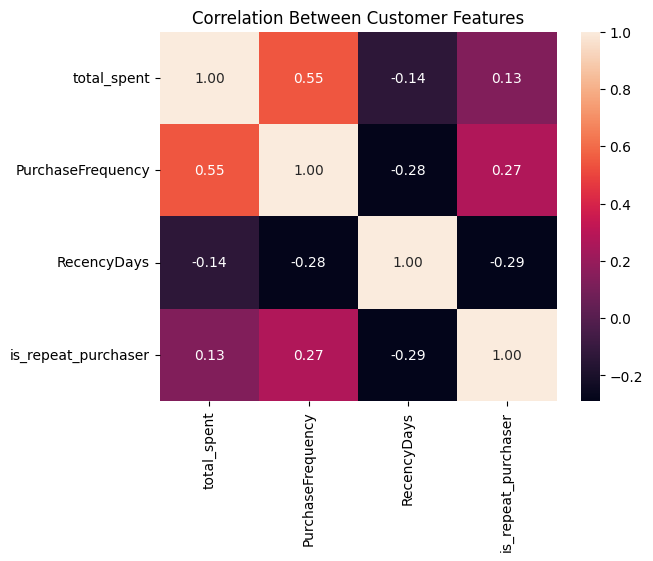

In [ ]:
corr = df[[
    "total_spent",
    "PurchaseFrequency",
    "RecencyDays",
    "is_repeat_purchaser"
]].corr()

sns.heatmap(corr, annot=True, fmt=".2f")

plt.title("Correlation Between Customer Features")
plt.show()

#**Task 3: Exploratory Data Analysis and Visualization**

In [ ]:
df.head()


,CustomerID,total_spent,PurchaseFrequency,LastPurchaseDate,Recency,AverageOrderValue,is_repeat_purchaser
0,12346.0,77183.60,1,2011-01-18 10:01:00,262,77183.600,0
1,12347.0,2790.86,5,2011-08-02 08:48:00,66,558.172,1
2,12348.0,1437.24,4,2011-09-25 13:13:00,12,359.310,0
3,12350.0,294.40,1,2011-02-02 16:01:00,246,294.400,0
4,12352.0,1154.01,6,2011-09-28 14:58:00,8,192.335,1


In [ ]:
print(df.shape)
print(df.isnull().sum())

(3701, 7)
CustomerID             0
total_spent            0
PurchaseFrequency      0
LastPurchaseDate       0
Recency                0
AverageOrderValue      0
is_repeat_purchaser    0
dtype: int64


In [ ]:
df["is_repeat_purchaser"].value_counts()

,count
is_repeat_purchaser,
0,1905
1,1796


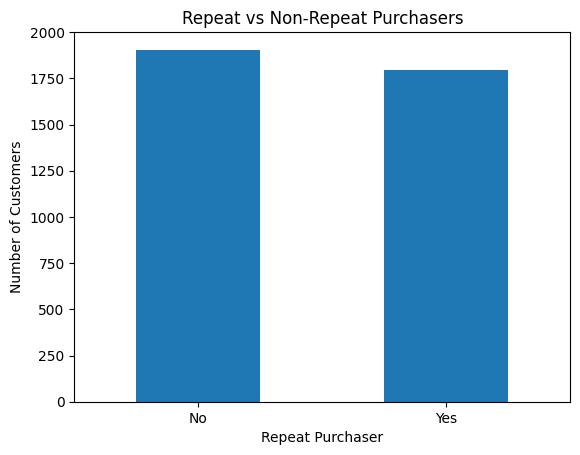

In [ ]:
df["is_repeat_purchaser"].value_counts().plot(kind="bar")

plt.title("Repeat vs Non-Repeat Purchasers")
plt.xlabel("Repeat Purchaser")
plt.ylabel("Number of Customers")
plt.xticks([0, 1], ["No", "Yes"], rotation=0)

plt.show()

The target classes are fairly balanced. There are 1,914 non-repeat purchasers and 1,793 repeat purchasers, so there is not a major class imbalance.

In [ ]:
df.groupby("is_repeat_purchaser")["total_spent"].mean()

,total_spent
is_repeat_purchaser,
0,787.748080
1,2708.992261


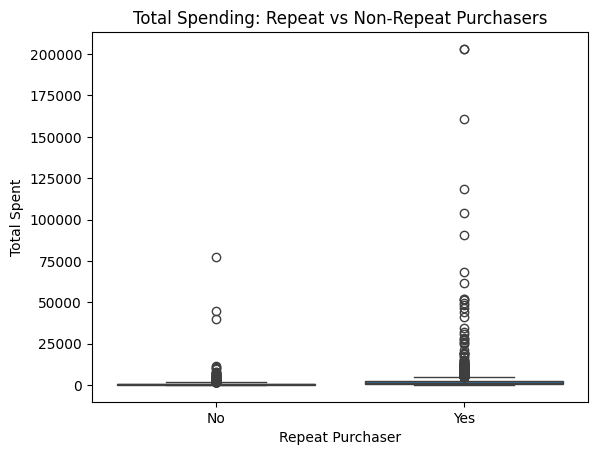

In [ ]:
sns.boxplot(
    data=df,
    x="is_repeat_purchaser",
    y="total_spent"
)

plt.title("Total Spending: Repeat vs Non-Repeat Purchasers")
plt.xlabel("Repeat Purchaser")
plt.ylabel("Total Spent")
plt.xticks([0, 1], ["No", "Yes"])

plt.show()

In [ ]:
df.groupby("is_repeat_purchaser")["PurchaseFrequency"].mean()

,PurchaseFrequency
is_repeat_purchaser,
0,2.027297
1,5.379176


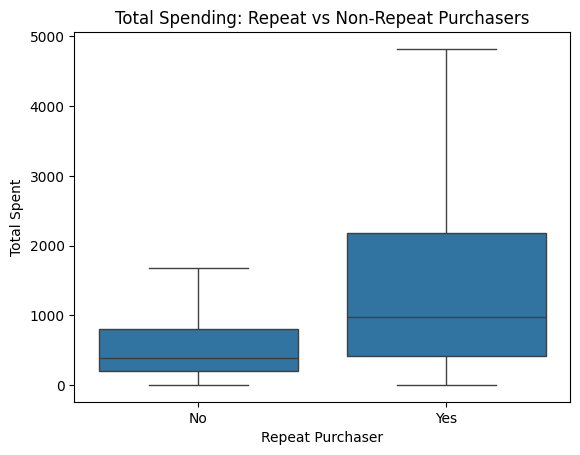

In [ ]:
sns.boxplot(
    data=df,
    x="is_repeat_purchaser",
    y="total_spent",
    showfliers=False
)

plt.title("Total Spending: Repeat vs Non-Repeat Purchasers")
plt.xlabel("Repeat Purchaser")
plt.ylabel("Total Spent")
plt.xticks([0, 1], ["No", "Yes"])

plt.show()

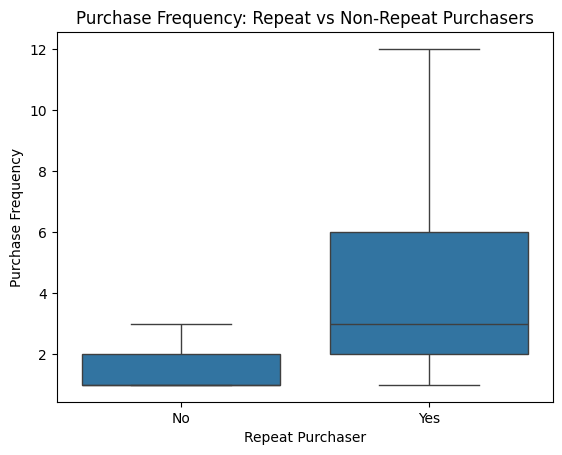

In [ ]:
sns.boxplot(
    data=df,
    x="is_repeat_purchaser",
    y="PurchaseFrequency",
    showfliers=False
)

plt.title("Purchase Frequency: Repeat vs Non-Repeat Purchasers")
plt.xlabel("Repeat Purchaser")
plt.ylabel("Purchase Frequency")
plt.xticks([0, 1], ["No", "Yes"])

plt.show()

In [ ]:
#Exploratory Data Analysis — completed by Meena

Repeat purchasers tend to spend more overall than non-repeat purchasers. The median and spending range are both higher for repeat purchasers.

Repeat purchasers had a higher purchase frequency in the past. Their median purchase frequency is around 3, compared with about 1 for non-repeat purchasers.

In [ ]:
df["LastPurchaseDate"] = pd.to_datetime(df["LastPurchaseDate"])

reference_date = df["LastPurchaseDate"].max()

df["RecencyDays"] = (reference_date - df["LastPurchaseDate"]).dt.days

df.groupby("is_repeat_purchaser")["RecencyDays"].mean()

,RecencyDays
is_repeat_purchaser,
0,116.727034
1,65.302895


Customers who became repeat purchasers had more recent past purchases. On average, their last purchase was about 66 days ago compared with about 118 days for non-repeat purchasers.

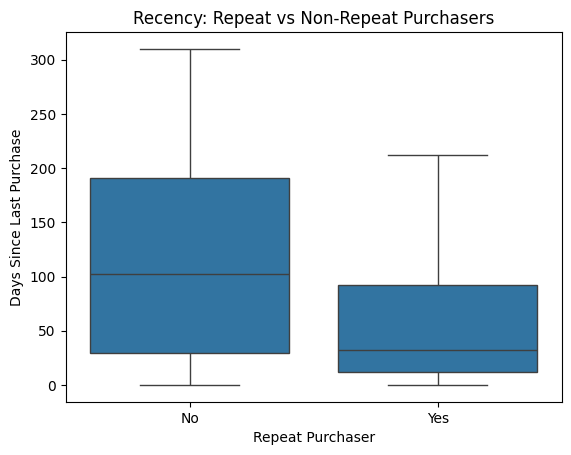

In [ ]:
sns.boxplot(
    data=df,
    x="is_repeat_purchaser",
    y="RecencyDays",
    showfliers=False
)

plt.title("Recency: Repeat vs Non-Repeat Purchasers")
plt.xlabel("Repeat Purchaser")
plt.ylabel("Days Since Last Purchase")
plt.xticks([0, 1], ["No", "Yes"])

plt.show()

Repeat purchasers tend to have made their last purchase more recently. Their median recency is much lower than non-repeat purchasers.

In [ ]:
df[["total_spent", "PurchaseFrequency", "RecencyDays", "is_repeat_purchaser"]].corr()

,total_spent,PurchaseFrequency,RecencyDays,is_repeat_purchaser
total_spent,1.000000,0.545224,-0.135642,0.132583
PurchaseFrequency,0.545224,1.000000,-0.281646,0.269942
RecencyDays,-0.135642,-0.281646,1.000000,-0.290119
is_repeat_purchaser,0.132583,0.269942,-0.290119,1.000000


Purchase frequency has a positive relationship with repeat purchasing, while recency has a negative relationship. This means customers who purchased more often and more recently were more likely to become repeat purchasers.

In [ ]:
df[["total_spent", "PurchaseFrequency", "RecencyDays"]].describe()

,total_spent,PurchaseFrequency,RecencyDays
count,3701.000000,3701.000000,3701.000000
mean,1720.078409,3.653877,91.772224
std,7243.264289,6.206658,88.599385
min,2.900000,1.000000,0.000000
25%,283.730000,1.000000,16.000000
50%,594.000000,2.000000,60.000000
75%,1429.840000,4.000000,148.000000
max,203146.860000,143.000000,310.000000


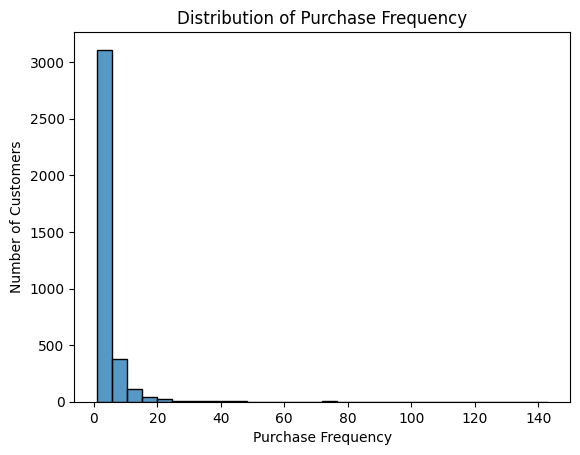

In [ ]:
sns.histplot(df["PurchaseFrequency"], bins=30)

plt.title("Distribution of Purchase Frequency")
plt.xlabel("Purchase Frequency")
plt.ylabel("Number of Customers")

plt.show()

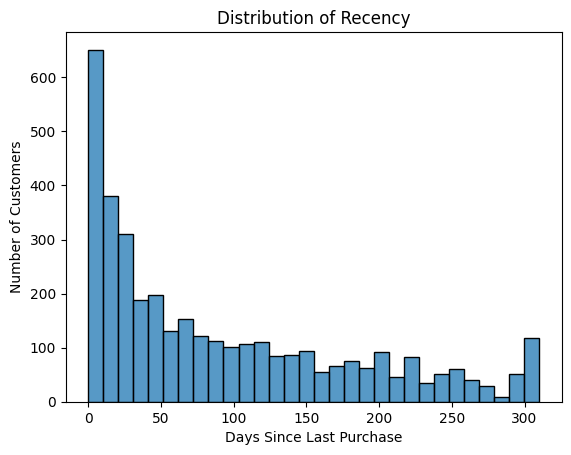

In [ ]:
sns.histplot(df["RecencyDays"], bins=30)

plt.title("Distribution of Recency")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Number of Customers")

plt.show()


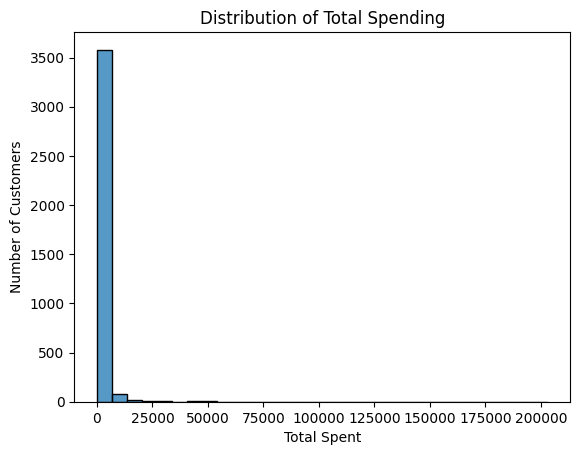

In [ ]:
sns.histplot(df["total_spent"], bins=30)

plt.title("Distribution of Total Spending")
plt.xlabel("Total Spent")
plt.ylabel("Number of Customers")

plt.show()

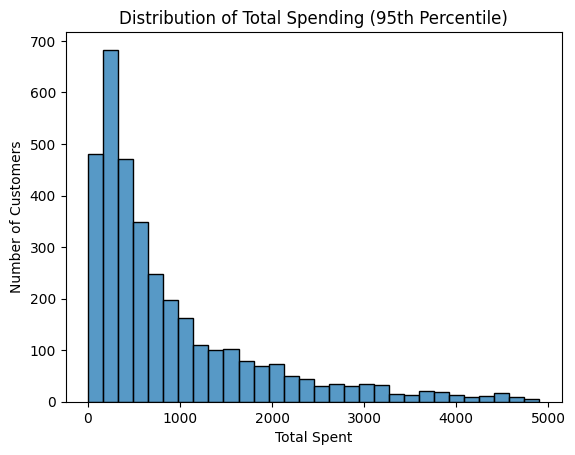

In [ ]:
limit = df["total_spent"].quantile(0.95)

sns.histplot(
    df[df["total_spent"] <= limit]["total_spent"],
    bins=30
)

plt.title("Distribution of Total Spending (95th Percentile)")
plt.xlabel("Total Spent")
plt.ylabel("Number of Customers")

plt.show()

Initial EDA Findings
* Repeat purchasers tend to spend more than non-repeat purchasers.
* Repeat purchasers purchase more frequently.
* Repeat purchasers tend to have purchased more recently.
* Purchase frequency has a positive relationship with repeat purchasing.
* Recency has a negative relationship with repeat purchasing.
* Purchase frequency is highly right-skewed; most customers made only a few purchases.
* Recency is right-skewed; many customers purchased recently, while fewer customers had long gaps since their last purchase.
* Total spending is highly right-skewed, with a small number of very high-spending customers.
* **What this means**:
These early results suggest that purchase frequency and recency may help predict which customers are likely to purchase again.



Summary Statistics and Key Predictive Features

In [ ]:
df.groupby("is_repeat_purchaser")["AverageOrderValue"].mean()

,AverageOrderValue
is_repeat_purchaser,
0,409.063072
1,402.273200


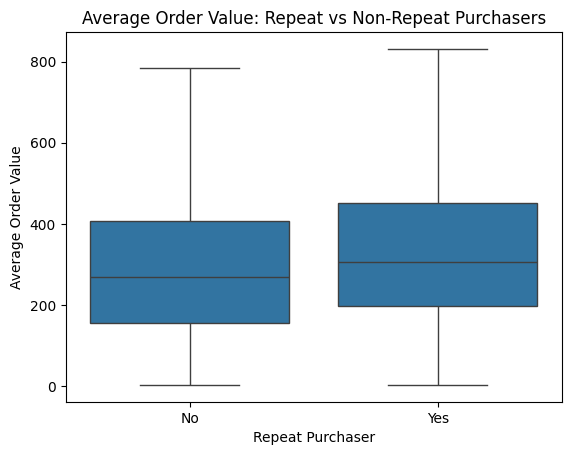

In [ ]:
sns.boxplot(
    data=df,
    x="is_repeat_purchaser",
    y="AverageOrderValue",
    showfliers=False
)


plt.title("Average Order Value: Repeat vs Non-Repeat Purchasers")
plt.xlabel("Repeat Purchaser")
plt.ylabel("Average Order Value")
plt.xticks([0, 1], ["No", "Yes"])

plt.show()

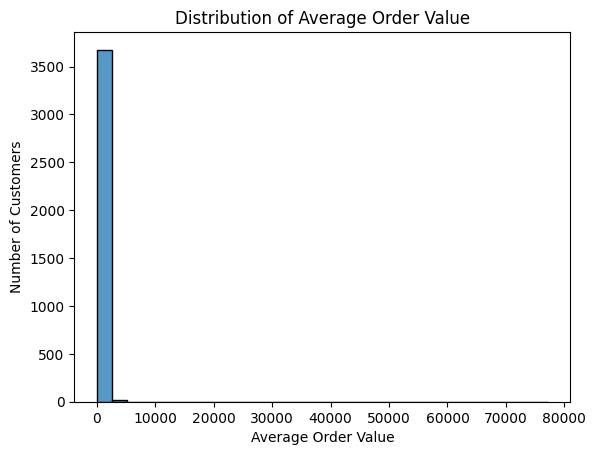

In [ ]:
sns.histplot(df["AverageOrderValue"], bins=30)

plt.title("Distribution of Average Order Value")
plt.xlabel("Average Order Value")
plt.ylabel("Number of Customers")

plt.show()
#

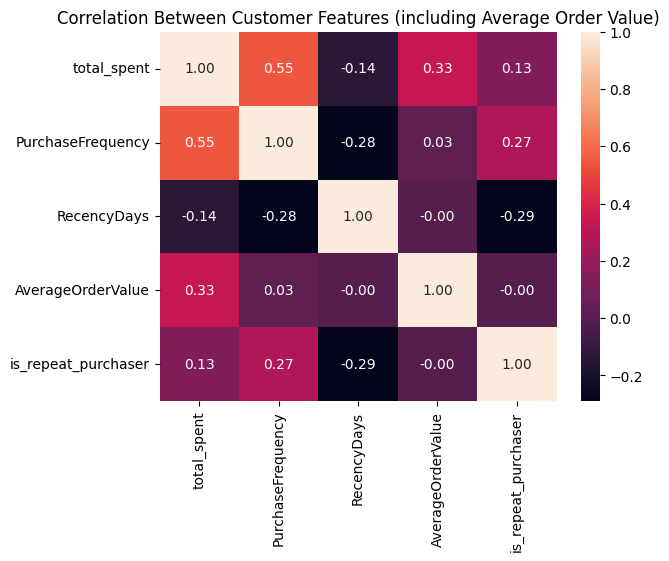

In [ ]:
#Updated correlation matrix including AverageOrderValue alongside the other features
corr_full = df[[
    "total_spent",
    "PurchaseFrequency",
    "RecencyDays",
    "AverageOrderValue",
    "is_repeat_purchaser"
]].corr()

sns.heatmap(corr_full, annot=True, fmt=".2f")

plt.title("Correlation Between Customer Features (including Average Order Value)")
plt.show()

In [ ]:
print(corr_full["is_repeat_purchaser"].sort_values(ascending=False))

is_repeat_purchaser    1.000000
PurchaseFrequency      0.269942
total_spent            0.132583
AverageOrderValue     -0.002479
RecencyDays           -0.290119
Name: is_repeat_purchaser, dtype: float64


**Key Predictive Features**

We ranked the four customer-level features by how strongly each one correlates with wether a customer becomes a repear purchaser:

1. **Recency** (days since last purchase) - correlation: -0.29
2. **Purchase Frequency** - correlation: : +0.27
3. **Total Spent** - correlation: +0.13
4. **Average Order Value** - correlation: -0.00

Recency and Purchase Frequency are the two strongest predictors. Customers who purchased more recently, and customers who purchased more often, were both more likely to come back. Total Spent has a weaker relatioship, overlaps with Purchase Frequency (customers who order more often naturally spend more overall). Average Order Value (AOV) shows almost no relationship with repeat purchasing. How much a customer spends per order doesn't predict wether they'll return. Repeat and non-repeat purchasers spend nearly the same amount per order on average ( $ 406.94 vs. $ 410.67).

**Takeaway for modeling:** Recency and Purchase Frequency should be the core Features going into phase 2. Total Spent may add some value, but, for right now it should be double-looked at for possible overlap with Purchase Frequency. Average Order Value is unlikelt to help the model much on its own.  
